<img src='./pic/sharif-main-logo.png' alt="SUT logo" width=300 height=300 align=left class="saturate" > <br>

<div dir=ltr align=center>
<font color=0F5298 size=7>
    Machine Learning <br>
<font color=2565AE size=5>
    Computer Engineering Department <br>
    Fall 2024 <br>
<font color=3C99D size=5>
    Practical Assignment 1 - Supervised Learning <br>
<font color=696880 size=4>
    Erfan Salima, Nikan Vasei, Fatemeh Shiri, Sarina Heshmati

____

# Personal Data

In [1]:
student_number = '401102789'
Name = 'Seyed Ali'
Last_Name = 'Vakilzadeh Hatefi'

# Libraries

In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler, PolynomialFeatures

# Polynomial Regression & Bias-Variance Tradeoff (100 Points)

<font size=4>
Author: Nikan Vasei

## Introduction
In this part, we will explore the **bias-variance tradeoff** using polynomial regression models. Polynomial regression allows us to model complex relationships between an independent variable $X$ and a dependent variable $y$ by introducing higher-degree polynomial terms. However, increasing the complexity of the model can lead to **overfitting** or **underfitting**, which are key concepts in the bias-variance tradeoff.

## Plan
1. **Create a synthetic dataset**: Use the provided quadratic function to generate $X$ and $y$ with noise.
2. **Split the dataset**: Divide the data into training and test sets to evaluate model generalization.
3. **Train polynomial models**: Fit polynomial regression models with degrees ranging from 1 to 10 (or more).
4. **Evaluate performance**: Calculate the MSE for both training and test sets and compare the errors for different polynomial degrees.
5. **Analyze the results**: Use plots to visualize how the error on the training and test sets changes as the model complexity increases.

## Objective
The objective is to determine the degree of the polynomial that best models the relationship between $X$ and $y$ and balances both underfitting and overfitting, i.e., the degree that achieves the best generalization.

## 1. Create a synthetic dataset (15 Points)

Your first task is to define a function that generates a dataset with 1000 samples. The input values for the independent variable $X$ should be randomly selected within the range of **-3 to 3**. To make the dataset more realistic, add noise to the output using a normal distribution with a mean of 0 and a standard deviation of 10.

The relationship between the independent variable $X$ and the dependent variable $y$ is modeled by the following equation:

$$
y = 0.2X^6 - 0.5X^5 + 2X^4 - 5X^3 + 3X^2 - 10X + 5 + \text{noise}
$$

In [ ]:
def get_y_from_x(x, noise):
  return 0.2* x**6 - 0.5*x**5 + 2*x**4 - 5*x**3 + 3*x**2 - 10*x + 5 + noise


def generate_dataset(range_start, range_end, num_samples=1000, noise_std=10.0):
    # TODO: Generate dataset
    X=[]
    y=[]
    Noise= np.random.normal(0, noise_std, size=num_samples)
    for i in range(num_samples): # create data:
      X.append(np.random.uniform(range_start, range_end))
      y.append(get_y_from_x(X[i],Noise[i]))

    return X, y

Use a scatter plot to visualize the relationship between $X$ and $y$. This will help you understand the structure of the generated data before moving on to fitting models.

Text(0.5, 1.0, 'Scatter Plot of X vs y')

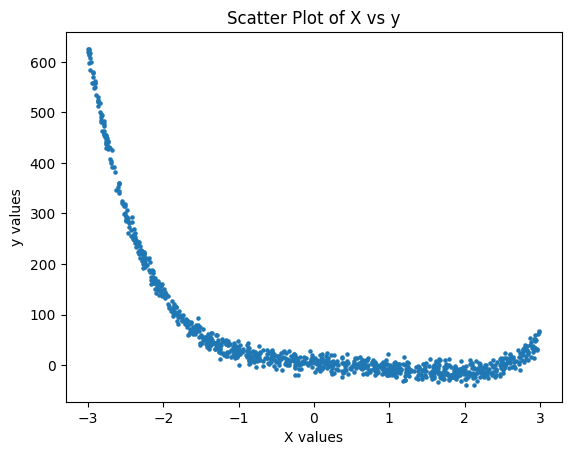

In [ ]:
X, y = generate_dataset(-3, 3)

# TODO: Visualize the dataset using scatter
plt.scatter(X, y, s=5)

plt.xlabel("X values")
plt.ylabel("y values")
plt.title("Scatter Plot of X vs y")

## 2. Splitting the Dataset (5 Points)

In this task, you should split the dataset into three parts:
1. **Training Set**
2. **In-Range Test Set**: This set should contain data within the same range as the training set.
3. **Out-of-Range Test Set**: This set should contain data in the range **[5, 7]**.

Ensure that the two test sets (In-Range and Out-of-Range) have the same length. You can use the `train_test_split` function from the `sklearn` library for convenience in splitting the data.

In [ ]:
# TODO: Split dataset into the training and the in-range testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
# TODO: Generate the out-of-range testing set
noise_std, start, end= 10 , 5, 7

Noise= np.random.normal(0, noise_std, size=len(X_test))
X_out_of_range=[]
y_out_of_range=[]
for i in range(len(X_test)):
  X_out_of_range.append(np.random.uniform(start, end))
  y_out_of_range.append(get_y_from_x(X_out_of_range[i],Noise[i]))

Again, you can use a scatter plot (or similar plots) to visualize the different sets and see their overall distributions.

Text(0.5, 1.0, 'Training Set vs. Test Sets')

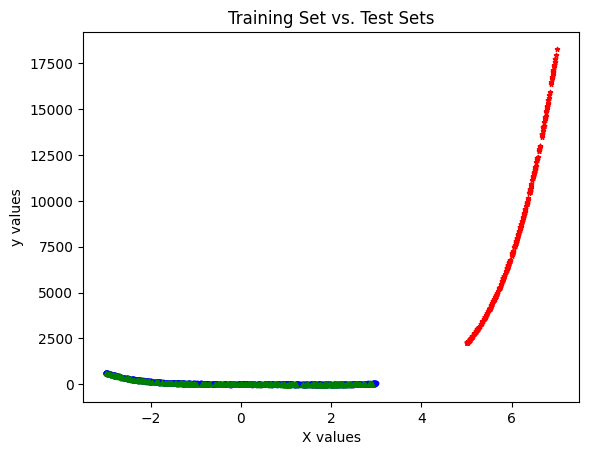

In [ ]:
# TODO: Visualize the sets using scatter (or other plots)
plt.scatter(X_train, y_train, color='blue', label='Train', s=10, marker='o')  # Training data
plt.scatter(X_test, y_test, color='green', label='Test', s=10, marker='^')
plt.scatter(X_out_of_range, y_out_of_range, color='red', label='Test', s=10, marker='*')

# Add labels and title
plt.xlabel("X values")
plt.ylabel("y values")
plt.title("Training Set vs. Test Sets")


## 3. Polynomial Regression Training (25 Points)

In this task, you should train polynomial regression models with varying degrees, ranging from degree = 2 to degree = 9. You can use the `preprocessing`, `linear_model`, and `pipeline` classes from the `sklearn` library to create and evaluate these models.

In [ ]:
from sklearn.pipeline import Pipeline
def train_models(X, y, degree):
    # TODO: Create and train a model based on the given degree
    model = Pipeline([
    ('poly', PolynomialFeatures(degree=degree)),
    ('linear', LinearRegression())
    ])

    # Fitting the model to the training data
    X = np.array(X)
    if len(X.shape) == 1:
      X = X.reshape(-1, 1)
    model.fit(X, y)

    return model

In [ ]:
models = {}
degree = 9

for i in range (2,degree+1):
  models[i] = train_models(X_train, y_train, i)

# TODO: Add the trained models with different degrees to the dict


## 4. Model Evaluation (20 Points)

In this task, you should evaluate the polynomial regression models on both test sets (In-Range Test Set and Out-of-Range Test Set) using Mean Squared Error (MSE). This evaluation will help you understand how well each model generalizes to different data ranges.

For each polynomial degree, compute the MSE on both the in-range test set and the out-of-range test set using the `mean_squared_error` function from the `sklearn` library.

In [ ]:
def evaluate_models(models, X_test, y_test):
    # TODO: Calculate MSE of each model (on the input test set).
    losses={}
    for degree, model in models.items():
      X_test=np.array(X_test)
      X_test=X_test.reshape(-1, 1)
      y_pred = model.predict(X_test)
      mse = mean_squared_error(y_test, y_pred)
      losses[degree]=mse
    return losses

In [ ]:
# TODO: Evaluate models on both the train and the test sets.
train_losses=evaluate_models(models, X_train, y_train)
test_losses=evaluate_models(models, X_test, y_test)
test_out_of_range_losses=evaluate_models(models, X_out_of_range, y_out_of_range)

## 5. Analyzing Model Scores (20 Points)

In this task, you will visualize and analyze the performance of polynomial regression models by plotting the **logarithm** (to better visualize differences) of losses (Mean Squared Error, MSE) for both training and test set and also by printing the losses related to each degree.

Make sure to train each model a few times to get a sense of variability in the results.

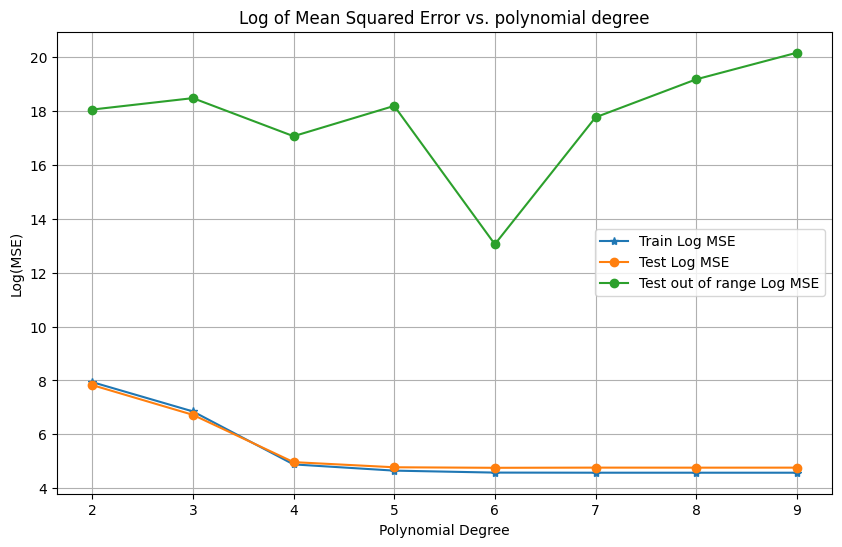

In [ ]:
# TODO: Calculate the log MSE for both the train and the test sets based on the model degrees from 2 to 9
log_train_losses = {degree: np.log(mse) for degree, mse in train_losses.items()}
log_test_losses = {degree: np.log(mse) for degree, mse in test_losses.items()}
log_losses_out_of_range = {degree: np.log(mse) for degree, mse in test_out_of_range_losses.items()}


# Plotting the log MSE
degrees = list(range(2, degree + 1))
plt.figure(figsize=(10, 6))

# Plot log MSE for all datasets
plt.plot(degrees, [log_train_losses[d] for d in degrees], label="Train Log MSE", marker='*')

plt.plot(degrees, [log_test_losses[d] for d in degrees], label="Test Log MSE", marker='o')

plt.plot(degrees, [log_losses_out_of_range[d] for d in degrees], label="Test out of range Log MSE", marker='o' )

# Labels and title
plt.xlabel('Polynomial Degree')
plt.ylabel('Log(MSE)')
plt.title('Log of Mean Squared Error vs. polynomial degree')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# TODO: Print each model loss on the training and the two test sets
print('Degree     Train MSE      IN-Range Test MSE    Out-of-Range Test MSE')
train_losses=list(train_losses)
test_losses=list(test_losses)
test_out_of_range_losses=list(test_out_of_range_losses)
for i in range (0, 8):
  print(f'{i+2:^8}   {train_losses[i]:<12.3f}   {test_losses[i]:<18.3f}   {test_out_of_range_losses[i]:<.3f}')


Degree     Train MSE      IN-Range Test MSE    Out-of-Range Test MSE
   2       2795.529       2505.012             69658121.411
   3       941.207        829.609              106506949.265
   4       131.650        143.194              25895635.175
   5       104.465        118.326              79813423.394
   6       97.091         116.009              468147.441
   7       96.695         116.809              52178543.069
   8       96.674         116.626              213946216.217
   9       96.644         116.714              575172192.221


## Conclusion (15 Points)

1. Based on your analysis of the training set loss, in-range test set loss, and out-of-range test set loss across different polynomial degrees, summarize what you have learned about the bias-variance tradeoff. How do these losses illustrate the tradeoff between model complexity and performance?


- <span style="color:cyan;">**Answer:** Write your answer here</span>
we concluded that adding dimension, and therefore complexity, can reduce bias of the model but increse the risk of overfitting, thereby increasing the variance of the model in this trade-off

2. Reflecting on the trends observed in the losses as polynomial degree increases, what conclusions can you draw about the effects of model complexity on overfitting and underfitting? How does this understanding help in selecting the appropriate polynomial degree for a model?

- <span style="color:cyan;">**Answer:** Write your answer here</span>
to find the optimal model with lowest bias-variance, we use validation (test) data to make sure the model is not commiting to an overfit, and minimize the loss function on both sets of data, thereby reaching an optimal degree of complexity in which the error for test (and training) data is minimal

# Regularization (50 Points)

<font size=4>
Author: Fatemeh Shiri

# **Introduction**

In this part, you will work with a real dataset that includes information about the cost of treatment of different patients. The cost of treatment depends on many factors: diagnosis, type of clinic, city of residence, age and so on. <a ref= 'https://github.com/stedy/Machine-Learning-with-R-datasets'>Reference</a>

Columns available:

* age: age of primary beneficiary

* sex: insurance contractor gender, female, male

* bmi: Body mass index, providing an understanding of body, weights that are relatively high or low relative to height, objective index of body weight (kg / m ^ 2) using the ratio of height to weight, ideally 18.5 to 24.9

* children: Number of children covered by health insurance / Number of dependents

* smoker: Smoking

* region: the beneficiary's residential area in the US, northeast, southeast, southwest, northwest.

* charges: Individual medical costs billed by health insurance

# Plan

- First, you will start by fitting a basic regression model using scikit-learn (sklearn) to establish a baseline for comparison. This basic regression model will serve as a reference point for evaluating the performance of more sophisticated models incorporating regularization techniques.

- Furthermore, you will apply L1 (Lasso) and L2 (Ridge) regularization techniques to refine your predictions and evaluate the impact of these methods on the accuracy of your results. Regularization is a technique used to prevent overfitting by adding a penalty term to the loss function, encouraging simpler models with smaller coefficients. L1 regularization (Lasso) encourages sparsity by penalizing the absolute values of coefficients, while L2 regularization (Ridge) penalizes the square of coefficients.

# Load and Explore

Load the dataset (as a dataframe) using pandas and display the top 5 rows of the dataframe

In [3]:
from google.colab import drive
drive.mount('/content/drive')
file_path = "/content/drive/My Drive/ML_HW1/Practical1/InsuranceData.csv"
df = pd.read_csv(file_path)
print(df.head())

Mounted at /content/drive
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


Get a brief description and do some EDA to get familiar with the dataset

In [4]:
# TODO: you can use .info() and .description()
print(df.info())
print("****\n")
print(df.describe())

print("****\n age:")
print(df['age'].describe())
print("****\n sex:")
print(df['sex'].describe())
print("****\n bmi:")
print(df['bmi'].describe())
print("****\n children:")
print(df['children'].describe())
print("****\n smoker:")
print(df['smoker'].describe())
print("****\n region:")
print(df['region'].describe())
print("****\n charges:")
print(df['charges'].describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None
****

               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.296250     0.000000   4740.287150
50%      39.000000    30.400000     1.000000   9382.033000
75%      51.000000    34.693750     2.000000  16639.9125

# Preprocessing

In [5]:
# TODO: apply any pre processing method you think is necessary
# Options: Normalization, Standardization, Outlier Detection, Imputation, Encoding, etc.

#map object(string) properties to binary values:
df=df
df['sex'] = df['sex'].map({'male': 1, 'female': 0})
df['smoker'] = df['smoker'].map({'yes': 1, 'no': 0})

# one-hot encoding of 4 regions to 4 columns, representing each region of living with 1 or 0
df = pd.get_dummies(df, columns=['region'])

#standardize columns below (mean of 0 and std of 1)
scaler = StandardScaler()
df[['age', 'bmi', 'children']] = scaler.fit_transform(df[['age', 'bmi', 'children']])




In [6]:
#we put all the features in X and final charges will be treated as y:
X=df.drop('charges', axis=1)
y=df['charges']
print(X.info())
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               1338 non-null   float64
 1   sex               1338 non-null   int64  
 2   bmi               1338 non-null   float64
 3   children          1338 non-null   float64
 4   smoker            1338 non-null   int64  
 5   region_northeast  1338 non-null   bool   
 6   region_northwest  1338 non-null   bool   
 7   region_southeast  1338 non-null   bool   
 8   region_southwest  1338 non-null   bool   
dtypes: bool(4), float64(3), int64(2)
memory usage: 57.6 KB
None


# Training

Fit a linear regressor to the data.

In [7]:
# TODO: Use sklearn
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

Get the coefficients of the variables and visualize it

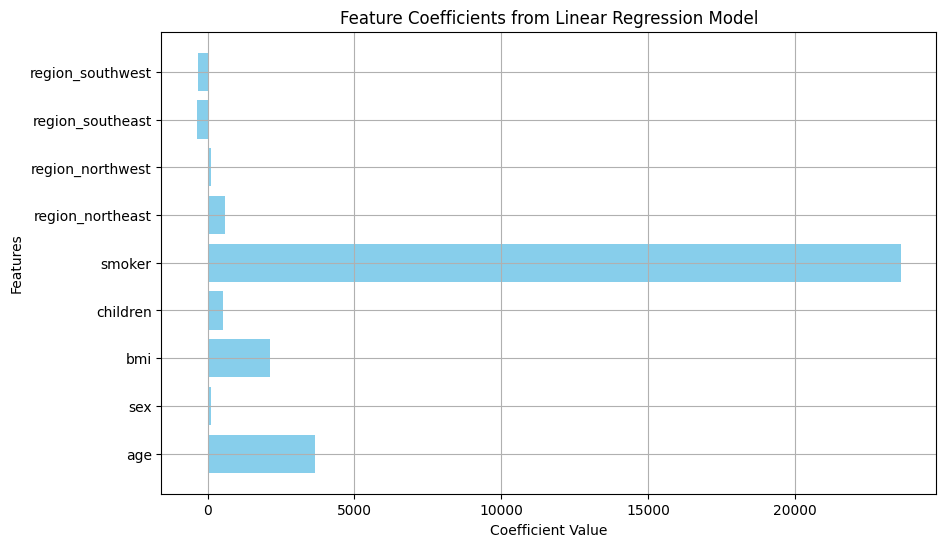

In [8]:
# TODO:
coefficients = model.coef_
feature_names = X.columns
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

def visualize_model_coeff_vals(feature_names, coefficients , title):
  plt.figure(figsize=(10, 6))
  plt.barh(coef_df['Feature'], coef_df['Coefficient'], color='skyblue')
  plt.xlabel('Coefficient Value')
  plt.ylabel('Features')
  plt.title(title)
  plt.grid(True)
  plt.show()

visualize_model_coeff_vals(feature_names ,coefficients, 'Feature Coefficients from Linear Regression Model')


# Regularization

L1 regularization, also known as Lasso (Least Absolute Shrinkage and Selection Operator) regularization, is a technique used in regression models that encourages simplicity and sparsity in the model coefficients. This is achieved by adding a penalty equal to the absolute value of the magnitude of coefficients to the loss function.\
</br>
Train a regression model using L1 regularization.

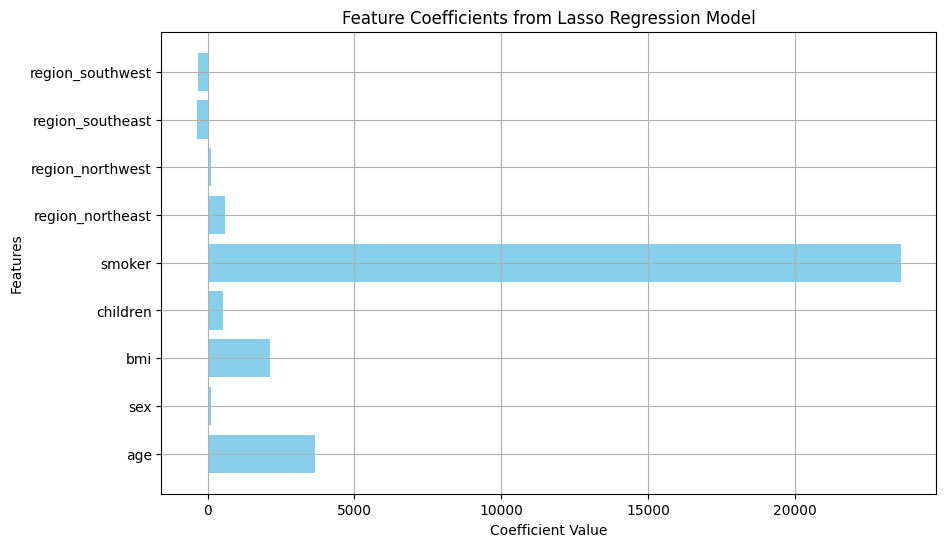

In [9]:
# TODO: Use Lasso from sklearn library
lasso_model = Lasso(alpha=1.0)
lasso_model.fit(X_train, y_train)

visualize_model_coeff_vals(lasso_model.coef_ ,coefficients, 'Feature Coefficients from Lasso Regression Model')

L2 regularization, also known as Ridge regularization, is a technique used in regression models to prevent overfitting by adding a penalty equivalent to the square of the magnitude of coefficients to the loss function.
</br>
Train a regression model using L2 regularization.

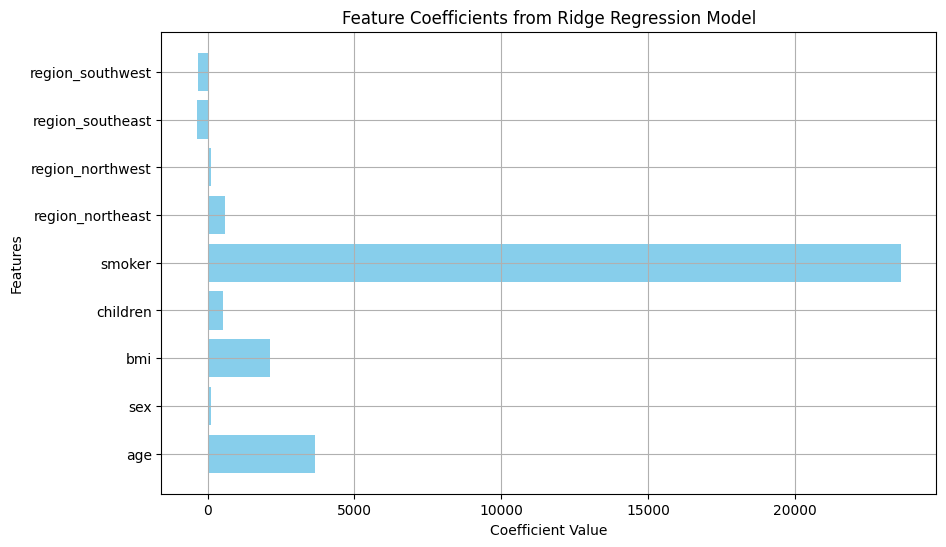

In [10]:
# TODO: Use Ridge from sklearn library
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)

visualize_model_coeff_vals(lasso_model.coef_ ,coefficients,  'Feature Coefficients from Ridge Regression Model')

Test different regularization parameters (alpha) for each regularization method using cross validation and visualize the coefficients of the variables. Use MAPE for evaluation.

**Mean Absolute Percentage Error (MAPE)**:


 is a widely used metric for evaluating the accuracy of forecasting models. It quantifies the prediction error as a percentage, providing an intuitive measure of how far off predictions are from actual values. MAPE is defined as the average of the absolute percentage errors between predicted values and actual values. The formula for calculating MAPE is:

$$
\text{MAPE} = \frac{100}{N} \sum_{t=1}^{N} \left| \frac{A_t - F_t}{A_t} \right|
$$
    
Where:
- $N$ is the number of observations,
- $A_t$ is the actual value,
- $F_t$ is the forecasted value.

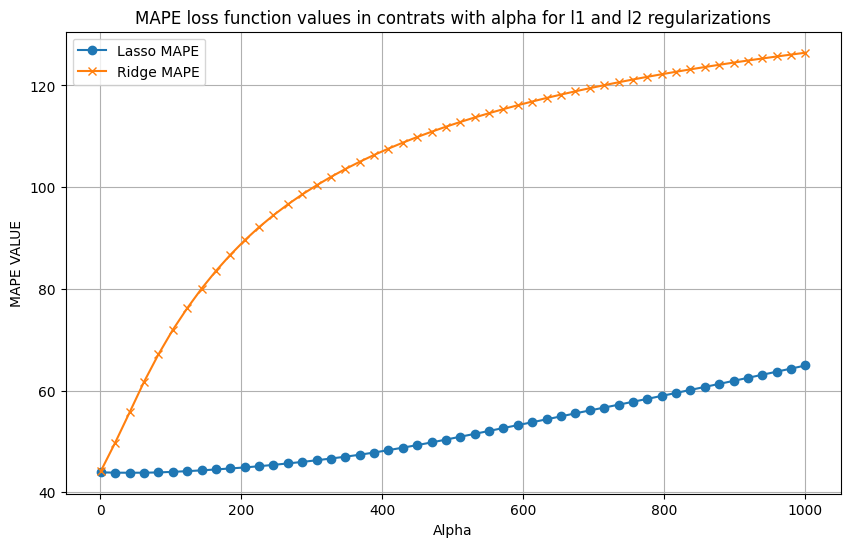

In [11]:
# TODO: Use folding methods and mape from sklearn library
def calculate_MAPE(At , Ft):
  return 100* np.mean(np.abs((At - Ft) / At))

def fit_models_kfold(X, y, alpha=1.0, k_folds=5):

    kf = KFold(n_splits=k_folds, shuffle=True, random_state=42)
    scaler = StandardScaler()
    ridge_coefficients = np.zeros(X.shape[1])
    lasso_coefficients = np.zeros(X.shape[1])
    ridge_mape_scores = []
    lasso_mape_scores = []

    for train_index, test_index in kf.split(X):
      X_train, X_test = X.iloc[train_index], X.iloc[test_index]
      y_train, y_test = y.iloc[train_index], y.iloc[test_index]

      # # Standardize
      # X_train_scaled = scaler.fit_transform(X_train)
      # X_test_scaled = scaler.transform(X_test)

      # Ridge
      ridge_model = Ridge(alpha)
      ridge_model.fit(X_train, y_train)
      y_pred_ridge = ridge_model.predict(X_test)

      ridge_coefficients+= ridge_model.coef_ /kf.get_n_splits()
      ridge_mape_scores.append(calculate_MAPE(y_test, y_pred_ridge))

      # Lasso
      lasso_model = Lasso(alpha)
      lasso_model.fit(X_train, y_train)
      y_pred_lasso = lasso_model.predict(X_test)

      lasso_coefficients+= lasso_model.coef_ /kf.get_n_splits()
      lasso_mape_scores.append(calculate_MAPE(y_test, y_pred_lasso))

      avg_ridge_mape = np.mean(ridge_mape_scores)
      avg_lasso_mape = np.mean(lasso_mape_scores)

    results = {
        'ridge_coefficients': ridge_coefficients,
        'lasso_coefficients': lasso_coefficients,
        'ridge_mape': avg_ridge_mape,
        'lasso_mape': avg_lasso_mape
    }
    return results

def find_results_for_different_alphas(X, y, alpha_range):
       final_results = {
        'alpha': [],
        'lasso_mape': [],
        'ridge_mape': [],
        'lasso_coefficients': [],
        'ridge_coefficients': []
       }
       for alpha in alpha_range:
        results=fit_models_kfold(X, y, alpha)
        final_results['alpha'].append(alpha)
        final_results['lasso_mape'].append(results['lasso_mape'])
        final_results['ridge_mape'].append(results['ridge_mape'])
        final_results['lasso_coefficients'].append(results['lasso_coefficients'])
        final_results['ridge_coefficients'].append(results['ridge_coefficients'])

       return final_results

def plot_MAPE_vals(final_results):
      plt.figure(figsize=(10, 6))
      plt.plot(alpha_range, final_results['lasso_mape'], label='Lasso MAPE', marker='o')
      plt.plot(alpha_range, final_results['ridge_mape'], label='Ridge MAPE', marker='x')

      plt.xlabel('Alpha')
      plt.ylabel('MAPE VALUE')
      plt.title('MAPE loss function values in contrats with alpha for l1 and l2 regularizations')
      plt.legend()
      plt.grid()
      plt.show()

alpha_range = np.linspace(1, 1000, 50)
final_results=find_results_for_different_alphas(X_train, y_train, alpha_range)
plot_MAPE_vals(final_results)

Add extra variables to dataset to make model more complex, then compare the results.

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.641e+09, tolerance: 1.137e+07
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.738e+09, tolerance: 1.118e+07
  model = cd_fast.enet_coordinate_descent(


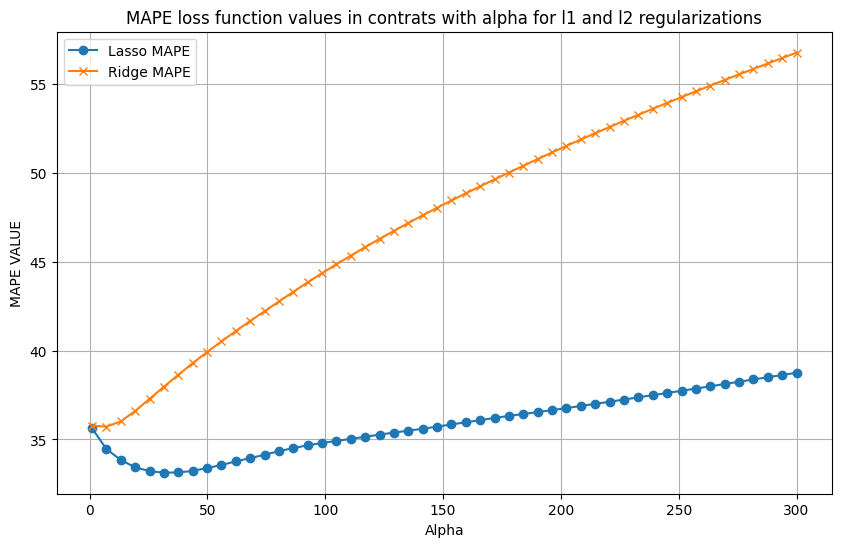

In [12]:
# TODO: Increase No. of dimensions using PolynomialFeatures from sklearn
alpha_range = np.linspace(1, 300, 50)
poly = PolynomialFeatures(degree=3, interaction_only=False, include_bias=False)
X_poly = poly.fit_transform(X_train)
feature_names = poly.get_feature_names_out(input_features=X.columns)
X_poly = pd.DataFrame(X_poly, columns=feature_names)
plot_MAPE_vals(find_results_for_different_alphas(X_poly, y_train, alpha_range))

Report your best model with its evaluated results.

In [13]:
# TODO: Print each model's loss on the training and the test set.
# TODO: Print each model's loss on the training and the test set.
import warnings
from sklearn.exceptions import ConvergenceWarning
def print_best_alpha(X, y):
    results = find_results_for_different_alphas(X, y,alpha_range)
    lasso_alpha = alpha_range[np.argmin(results['lasso_mape'])]
    ridge_alpha = alpha_range[np.argmin(results['ridge_mape'])]
    print(f"Lasso best alpha: {lasso_alpha}")
    print(f"Ridge best alpha: {ridge_alpha}\n")

def print_loss(X, y):
    results = find_results_for_different_alphas(X, y,alpha_range)
    print(f"Lasso MAPE: {results['lasso_mape'][np.argmin(results['lasso_mape'])]}")
    print(f"Ridge MAPE: {results['ridge_mape'][np.argmin(results['lasso_mape'])]}\n")



warnings.filterwarnings("ignore", category=ConvergenceWarning)
print_best_alpha(X_poly, y_train)

print("Train Set:")
print_loss(X_poly, y_train)
X_poly2 = poly.fit_transform(X_test)
feature_names = poly.get_feature_names_out(input_features=X.columns)
X_poly2 = pd.DataFrame(X_poly2, columns=feature_names)
print("Test Set:")
print_loss(X_poly2, y_test)


Lasso best alpha: 31.51020408163265
Ridge best alpha: 7.1020408163265305

Train Set:
Lasso MAPE: 33.13235063536678
Ridge MAPE: 37.961907301411756

Test Set:
Lasso MAPE: 34.411936244807336
Ridge MAPE: 51.12911546044961



## Questions

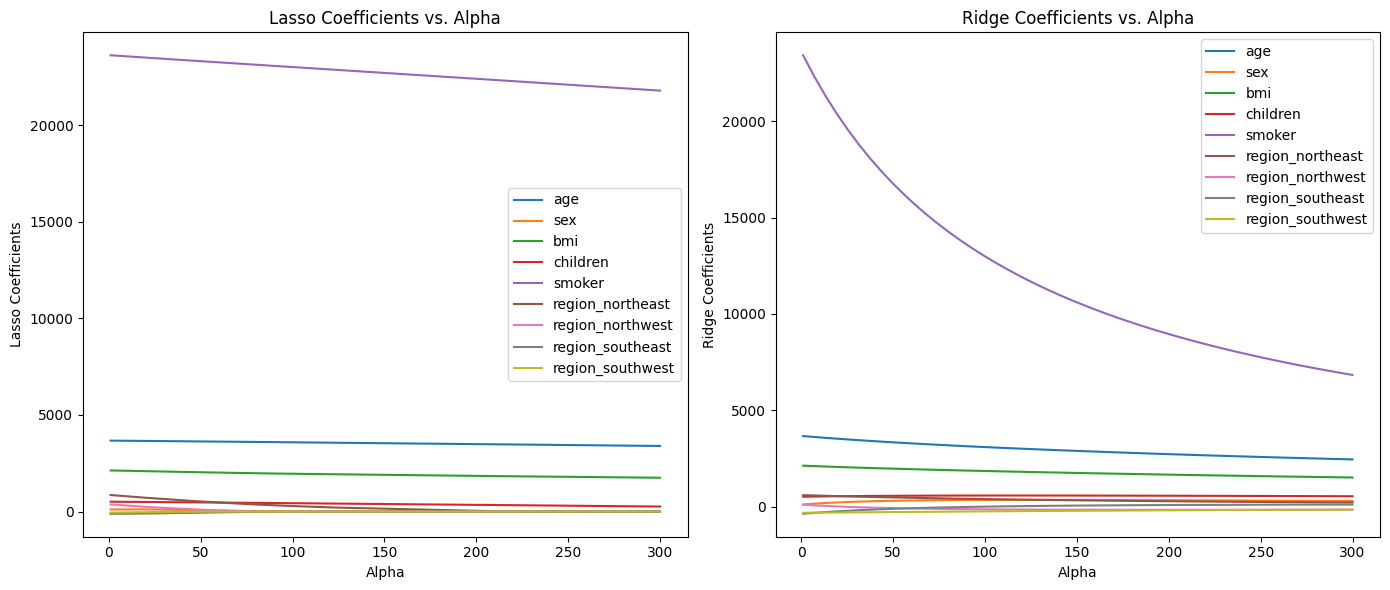

In [14]:
def plot_coeffs(X, y, alpha_range):
    results = find_results_for_different_alphas(X,y, alpha_range)
    lasso_coeffs = np.array(results['lasso_coefficients'])
    ridge_coeffs = np.array(results['ridge_coefficients'])

    plt.figure(figsize=(14, 6))

    plt.subplot(1, 2, 1)
    if lasso_coeffs.ndim == 1:
        lasso_coeffs = lasso_coeffs.reshape(-1, 1)
    for i in range(lasso_coeffs.shape[1]):
        plt.plot(results['alpha'], lasso_coeffs[:, i], label=X.columns[i])

    plt.xlabel('Alpha')
    plt.ylabel('Lasso Coefficients')
    plt.title('Lasso Coefficients vs. Alpha')
    plt.legend(loc='best')

    plt.subplot(1, 2, 2)
    if ridge_coeffs.ndim == 1:
        ridge_coeffs = ridge_coeffs.reshape(-1, 1)
    for i in range(ridge_coeffs.shape[1]):
        plt.plot(results['alpha'], ridge_coeffs[:, i], label=X.columns[i])

    plt.xlabel('Alpha')
    plt.ylabel('Ridge Coefficients')
    plt.title('Ridge Coefficients vs. Alpha')
    plt.legend(loc='best')
    plt.tight_layout()
    plt.show()

alpha_range = np.linspace(1, 300, 50)
plot_coeffs(X_train, y_train, alpha_range)

In [18]:
#storing best answers in csv file:
model = Lasso(alpha=31.5)
model.fit(X_poly, y_train)

file_path2 = "/content/drive/My Drive/ML_HW1/Practical1/InsuranceData_test.csv"
df2 = pd.read_csv(file_path2)
df2['sex'] = df2['sex'].map({'male': 1, 'female': 0})
df2['smoker'] = df2['smoker'].map({'yes': 1, 'no': 0})
df2 = pd.get_dummies(df2, columns=['region'])
scaler = StandardScaler()
df2[['age', 'bmi', 'children']] = scaler.fit_transform(df2[['age', 'bmi', 'children']])
df2['charges'] = 0
X2 = df2.drop('charges', axis=1)

X2_poly = poly.fit_transform(X2)
feature_names = poly.get_feature_names_out(input_features=X.columns)
X2_poly = pd.DataFrame(X2_poly, columns=feature_names)

predictions = model.predict(X2_poly)
df2['charges'] = predictions
df2.to_csv('/content/drive/My Drive/ML_HW1/Practical1/submission.csv', index=False)


1. Compare the weight distribution when applying L1/L2 regularization and their sparsity?




- <span style="color:cyan;">**Answer:** Write your answer here</span>


l1 regularization tends to produce more sparse results, whereas l2 will have a lower weight ditribution overall because of the penalty applied. Also, lasso tends to neglect some features with lower impact but ridge regression will keep their weights small but non-zero


2. How does the regularization parameter (alpha) affect each feature? Does it help to model's explainability?

- <span style="color:cyan;">**Answer:** Write your answer here</span>

both models will shrink in weights of coefficients, however, lasso will tend to use lesser amount of features whereas ridge will not reult in factors to become exactly zero.

3. How does the regularization affect dimension expansion?

- <span style="color:cyan;">**Answer:** Write your answer here</span>
It is clear that increase in dimension increases complexity. to tackle the overfitting problem, lasso regression tends to neglect unimportant factors added, while ridge regression will have them maintaining a small coefficient unless they have a clear impact.